In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [45]:
df=pd.read_csv(r"C:\Users\anant\OneDrive\Desktop\Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [10]:
df.drop(['Age', 'Gender','CustomerID'], axis=1, inplace=True)


In [11]:
df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


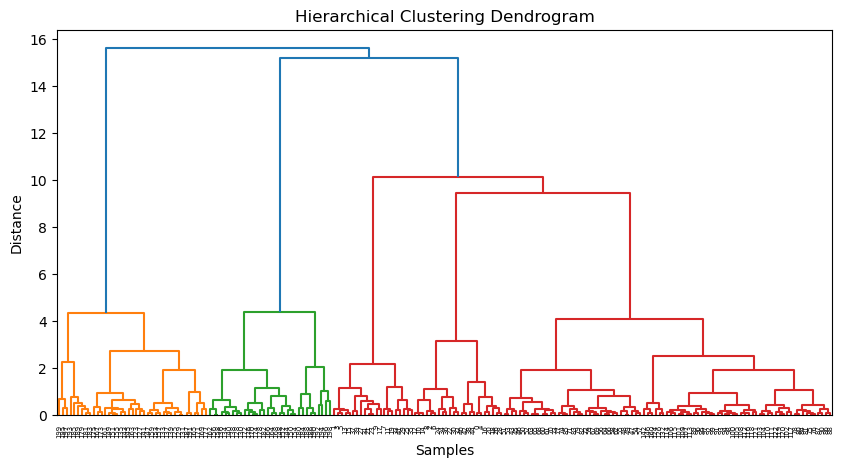

In [21]:
#Dendrogram (to find optimal clusters)
plt.figure(figsize=(10, 5))
linked = linkage(scaled_data, method='ward')
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [22]:
#Apply Agglomerative Clustering

In [30]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = hc.fit_predict(scaled_data)

print("Cluster Labels:", labels[:10])


Cluster Labels: [0 0 0 0 0 0 0 0 0 0]


In [26]:
sil_score = silhouette_score(scaled_data, labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.4610481446570447


In [33]:
#here the sihhouette score decrease so we need to find cluster value

In [34]:
for k in range(2, 10):
    hc = AgglomerativeClustering(n_clusters=k)
    labels = hc.fit_predict(scaled_data)
    print(f"K = {k}, Silhouette Score = {silhouette_score(scaled_data, labels)}")


K = 2, Silhouette Score = 0.3842337621772661
K = 3, Silhouette Score = 0.4610481446570447
K = 4, Silhouette Score = 0.4925507715349343
K = 5, Silhouette Score = 0.5538089226688662
K = 6, Silhouette Score = 0.5386761871036926
K = 7, Silhouette Score = 0.5197949293475768
K = 8, Silhouette Score = 0.4308617778221774
K = 9, Silhouette Score = 0.43768997758154127


In [35]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels = hc.fit_predict(scaled_data)

print("Cluster Labels:", labels[:10])


Cluster Labels: [4 3 4 3 4 3 4 3 4 3]


In [36]:
sil_score = silhouette_score(scaled_data, labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.5538089226688662


In [ ]:
#Silhouette Score is 0.6 

In [37]:
import pandas as pd

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))
print("Total Outliers:", outliers.sum().sum())

# remove outliers
df_clean_iqr = df[~outliers.any(axis=1)]


Total Outliers: 2


In [41]:
import pandas as pd
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df_capped = df.copy()

# Apply upper bound capping
for col in df.columns:
    df_capped[col] = df[col].apply(lambda x: upper_bound[col] if x > upper_bound[col] else x)

print(df_capped.head())


   Annual Income (k$)  Spending Score (1-100)
0                15.0                      39
1                15.0                      81
2                16.0                       6
3                16.0                      77
4                17.0                      40


In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_capped)


In [43]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels = hc.fit_predict(scaled_data)

print("Cluster Labels:", labels[:10])


Cluster Labels: [4 3 4 3 4 3 4 3 4 3]


In [44]:
sil_score = silhouette_score(scaled_data, labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.5545510023408176


we get an average cluster